<a href="https://colab.research.google.com/github/Akhil-Sharma30/cloud-computing-repo/blob/main/Assignment_3_Akhil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# Original set
my_set = {10, 20, 30, 40, 50}
print(f"Original set: {my_set}")

# Elements to swap (these are values, not indices)
element1 = 20
element2 = 40

# Convert set to a list to allow indexing and modification
my_list = list(my_set)

# Find the indices of the elements to swap
try:
    index1 = my_list.index(element1)
    index2 = my_list.index(element2)

    # Swap using a temporary variable
    temp = my_list[index1]
    my_list[index1] = my_list[index2]
    my_list[index2] = temp

    # Convert the list back to a set
    my_set_swapped = set(my_list)
    print(f"Set after swapping {element1} and {element2}: {my_set_swapped}")
except ValueError:
    print(f"One or both elements ({element1}, {element2}) not found in the set.")

Original set: {50, 20, 40, 10, 30}
Set after swapping 20 and 40: {40, 10, 50, 20, 30}


## Q1. Sales Data Analysis

### Part I: Randomized Sales Data Generation (NumPy)

In [1]:
# 1. Initialize Random Seed
import numpy as np
import pandas as pd

# Replace `your_roll_number` with your actual roll number.
# For demonstration, I'll use 12345.
roll_number = 12345  # <--- Please change this to your actual roll number
np.random.seed(roll_number)

print(f"Random seed initialized with roll number: {roll_number}")

Random seed initialized with roll number: 12345


### 2. Generate Sales Data

Creating a NumPy array for 12 months of sales data across four product categories: Electronics, Clothing, Home & Kitchen, and Sports. Sales values will be between 1000 and 5000 units per month, with randomization based on the seed.

In [2]:
# Generate sales data for 12 months (rows) and 4 product categories (columns)
# Sales values should be between 1000 and 5000
sales_data = np.random.randint(1000, 5001, size=(12, 4))

print("Generated Sales Data (NumPy Array):")
print(sales_data)

Generated Sales Data (NumPy Array):
[[1482 4557 4357 3177]
 [4492 4497 1382 4429]
 [1546 4613 3817 4190]
 [4441 4387 3702 3153]
 [4163 3807 2398 4280]
 [1882 1713 1267 4149]
 [2674 1081 2746 3214]
 [3311 1043 1231 1023]
 [2053 4000 4511 2311]
 [1701 1353 2883 1855]
 [3084 3624 1387 3812]
 [2148 2669 4215 1631]]


### 3. Convert to DataFrame

Converting the NumPy array into a Pandas DataFrame with appropriate column names and month names as the index.

### Part II: Data Manipulation and Analysis (Pandas)

#### 1. Display the first 5 rows and summary statistics of the DataFrame.

In [4]:
print("First 5 rows of the Sales DataFrame:")
display(sales_df.head())

print("\nSummary statistics of the Sales DataFrame:")
display(sales_df.describe())

First 5 rows of the Sales DataFrame:


,Electronics,Clothing,Home & Kitchen,Sports
Jan,1482,4557,4357,3177
Feb,4492,4497,1382,4429
Mar,1546,4613,3817,4190
Apr,4441,4387,3702,3153
May,4163,3807,2398,4280



Summary statistics of the Sales DataFrame:


,Electronics,Clothing,Home & Kitchen,Sports
count,12.000000,12.000000,12.000000,12.000000
mean,2748.083333,3112.000000,2824.666667,3102.000000
std,1131.455254,1448.254184,1285.766085,1152.870252
min,1482.000000,1043.000000,1231.000000,1023.000000
25%,1836.750000,1623.000000,1385.750000,2197.000000
50%,2411.000000,3715.500000,2814.500000,3195.500000
75%,3524.000000,4414.500000,3916.500000,4159.250000
max,4492.000000,4613.000000,4511.000000,4429.000000


#### 2. Calculate the total sales per category and total sales per month.

In [5]:
# Calculate total sales per category (sum of each column)
total_sales_per_category = sales_df.sum(axis=0)

print("\nTotal Sales Per Category:")
print(total_sales_per_category)

# Calculate total sales per month (sum of each row)
total_sales_per_month = sales_df.sum(axis=1)

print("\nTotal Sales Per Month:")
print(total_sales_per_month)


Total Sales Per Category:
Electronics       32977
Clothing          37344
Home & Kitchen    33896
Sports            37224
dtype: int64

Total Sales Per Month:
Jan    13573
Feb    14800
Mar    14166
Apr    15683
May    14648
Jun     9011
Jul     9715
Aug     6608
Sep    12875
Oct     7792
Nov    11907
Dec    10663
dtype: int64


#### 3. Calculate the average sales growth between consecutive months for each category.

#### 4. Add the following columns to the DataFrame:
*   **Total Sales**: Sum of all categories per month.
*   **Growth Rate**: Percentage change in Total Sales from the previous month.

In [7]:
# Calculate Total Sales (sum of all categories per month)
sales_df['Total Sales'] = sales_df.sum(axis=1)

# Calculate Growth Rate (percentage change in Total Sales from the previous month)
sales_df['Growth Rate'] = sales_df['Total Sales'].pct_change() * 100

print("Sales DataFrame with 'Total Sales' and 'Growth Rate' columns:")
display(sales_df.head())

Sales DataFrame with 'Total Sales' and 'Growth Rate' columns:


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,1482,4557,4357,3177,13573,NaN
Feb,4492,4497,1382,4429,14800,9.040006
Mar,1546,4613,3817,4190,14166,-4.283784
Apr,4441,4387,3702,3153,15683,10.708739
May,4163,3807,2398,4280,14648,-6.599503


#### 5. Apply a randomized discount:
*   If your roll number is even, apply a 10% discount to the Electronics category.
*   If odd, apply a 15% discount to the Clothing category.

In [8]:
# Apply randomized discount based on roll number
if roll_number % 2 == 0:
    # Even roll number: apply 10% discount to Electronics
    sales_df['Electronics'] = sales_df['Electronics'] * 0.90
    print(f"Applying 10% discount to Electronics category as roll number {roll_number} is even.")
else:
    # Odd roll number: apply 15% discount to Clothing
    sales_df['Clothing'] = sales_df['Clothing'] * 0.85
    print(f"Applying 15% discount to Clothing category as roll number {roll_number} is odd.")

print("\nSales DataFrame after applying discount:")
display(sales_df.head())

Applying 15% discount to Clothing category as roll number 12345 is odd.

Sales DataFrame after applying discount:


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,1482,3873.45,4357,3177,13573,NaN
Feb,4492,3822.45,1382,4429,14800,9.040006
Mar,1546,3921.05,3817,4190,14166,-4.283784
Apr,4441,3728.95,3702,3153,15683,10.708739
May,4163,3235.95,2398,4280,14648,-6.599503


### Part III: Visualizations (Matplotlib and Seaborn)

#### 1. Plot monthly sales trends for each category using line plots.

#### 2. Create the following plots:
*   Box plots to show the sales distribution for each category.

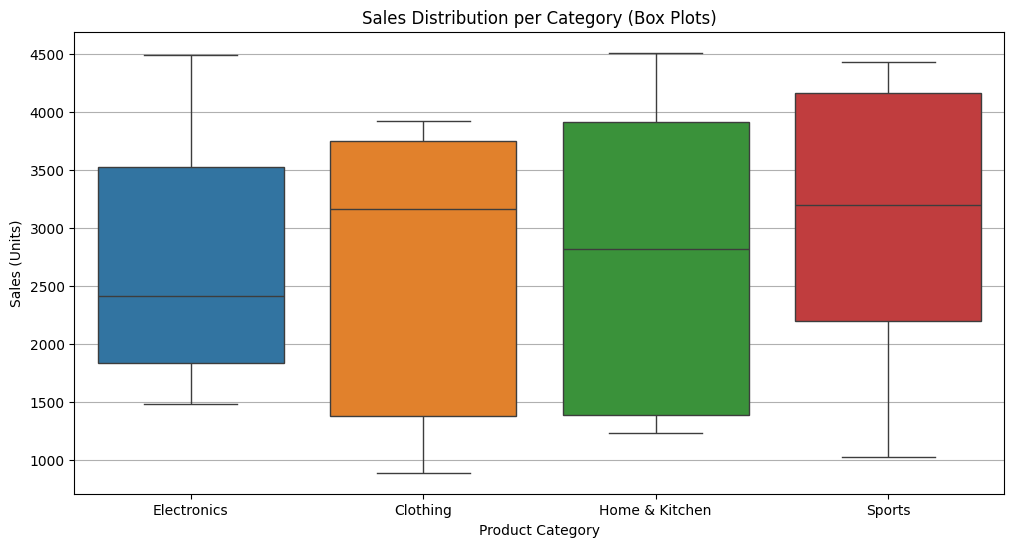

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=sales_df[['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']])
plt.title('Sales Distribution per Category (Box Plots)')
plt.xlabel('Product Category')
plt.ylabel('Sales (Units)')
plt.grid(True, axis='y')
plt.show()

## Q2. NumPy Array Operations

For the array: `array = np.array([[1, -2, 3], [-4, 5, -6]])`

In [11]:
import numpy as np

# Given array
array = np.array([[1, -2, 3], [-4, 5, -6]])
print("Original Array:")
print(array)

Original Array:
[[ 1 -2  3]
 [-4  5 -6]]


#### i. Find element-wise absolute value

In [12]:
# Element-wise absolute value
abs_array = np.abs(array)
print("\nElement-wise Absolute Value:")
print(abs_array)


Element-wise Absolute Value:
[[1 2 3]
 [4 5 6]]


#### ii. Find the 25th, 50th, and 75th percentile of flattened array, for each column, for each row.

In [13]:
# Flattened array percentiles
flattened_array = array.flatten()
print("\nPercentiles for Flattened Array:")
print(f"25th Percentile: {np.percentile(flattened_array, 25)}")
print(f"50th Percentile: {np.percentile(flattened_array, 50)}")
print(f"75th Percentile: {np.percentile(flattened_array, 75)}")

# Percentiles for each column
print("\nPercentiles for Each Column:")
for i, col in enumerate(array.T):
    print(f"Column {i+1}:")
    print(f"  25th Percentile: {np.percentile(col, 25)}")
    print(f"  50th Percentile: {np.percentile(col, 50)}")
    print(f"  75th Percentile: {np.percentile(col, 75)}")

# Percentiles for each row
print("\nPercentiles for Each Row:")
for i, row in enumerate(array):
    print(f"Row {i+1}:")
    print(f"  25th Percentile: {np.percentile(row, 25)}")
    print(f"  50th Percentile: {np.percentile(row, 50)}")
    print(f"  75th Percentile: {np.percentile(row, 75)}")


Percentiles for Flattened Array:
25th Percentile: -3.5
50th Percentile: -0.5
75th Percentile: 2.5

Percentiles for Each Column:
Column 1:
  25th Percentile: -2.75
  50th Percentile: -1.5
  75th Percentile: -0.25
Column 2:
  25th Percentile: -0.25
  50th Percentile: 1.5
  75th Percentile: 3.25
Column 3:
  25th Percentile: -3.75
  50th Percentile: -1.5
  75th Percentile: 0.75

Percentiles for Each Row:
Row 1:
  25th Percentile: -0.5
  50th Percentile: 1.0
  75th Percentile: 2.0
Row 2:
  25th Percentile: -5.0
  50th Percentile: -4.0
  75th Percentile: 0.5


#### iii. Mean, Median and Standard Deviation of flattened array, of each column, and each row

In [14]:
# Mean, Median, Std Dev for flattened array
print("\nStatistics for Flattened Array:")
print(f"  Mean: {np.mean(flattened_array)}")
print(f"  Median: {np.median(flattened_array)}")
print(f"  Standard Deviation: {np.std(flattened_array)}")

# Mean, Median, Std Dev for each column
print("\nStatistics for Each Column:")
print(f"  Mean: {np.mean(array, axis=0)}")
print(f"  Median: {np.median(array, axis=0)}")
print(f"  Standard Deviation: {np.std(array, axis=0)}")

# Mean, Median, Std Dev for each row
print("\nStatistics for Each Row:")
print(f"  Mean: {np.mean(array, axis=1)}")
print(f"  Median: {np.median(array, axis=1)}")
print(f"  Standard Deviation: {np.std(array, axis=1)}")


Statistics for Flattened Array:
  Mean: -0.5
  Median: -0.5
  Standard Deviation: 3.8622100754188224

Statistics for Each Column:
  Mean: [-1.5  1.5 -1.5]
  Median: [-1.5  1.5 -1.5]
  Standard Deviation: [2.5 3.5 4.5]

Statistics for Each Row:
  Mean: [ 0.66666667 -1.66666667]
  Median: [ 1. -4.]
  Standard Deviation: [2.05480467 4.78423336]


## Q3. NumPy Array Rounding Operations

For the array: `a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])`.

In [15]:
import numpy as np

# Given array
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])
print("Original Array:")
print(a)

Original Array:
[-1.8 -1.6 -0.5  0.5  1.6  1.8  3. ]


#### i. Find floor, ceiling and truncated value, rounded values

## Q4. Swap Two Elements in a List Using a Temporary Variable

In [17]:
# Original list
my_list = [10, 20, 30, 40, 50]
print(f"Original list: {my_list}")

# Elements to swap (e.g., at index 1 and index 3)
index1 = 1
index2 = 3

# Check if indices are valid
if 0 <= index1 < len(my_list) and 0 <= index2 < len(my_list):
    # Swap using a temporary variable
    temp = my_list[index1]
    my_list[index1] = my_list[index2]
    my_list[index2] = temp
    print(f"List after swapping elements at index {index1} and {index2}: {my_list}")
else:
    print("Invalid indices provided.")

Original list: [10, 20, 30, 40, 50]
List after swapping elements at index 1 and 3: [10, 40, 30, 20, 50]


In [18]:
# Original list
my_list = [10, 20, 30, 40, 50]
print(f"Original list: {my_list}")

# Elements to swap (e.g., at index 1 and index 3)
index1 = 1
index2 = 3

# Check if indices are valid
if 0 <= index1 < len(my_list) and 0 <= index2 < len(my_list):
    # Swap using a temporary variable
    temp = my_list[index1]
    my_list[index1] = my_list[index2]
    my_list[index2] = temp
    print(f"List after swapping elements at index {index1} and {index2}: {my_list}")
else:
    print("Invalid indices provided.")

Original list: [10, 20, 30, 40, 50]
List after swapping elements at index 1 and 3: [10, 40, 30, 20, 50]


## Q5. Swap Two Elements in a Set

In [19]:
# Original set
my_set = {10, 20, 30, 40, 50}
print(f"Original set: {my_set}")

# Elements to swap (these are values, not indices)
element1 = 20
element2 = 40

# Convert set to a list to allow indexing and modification
my_list = list(my_set)

# Find the indices of the elements to swap
try:
    index1 = my_list.index(element1)
    index2 = my_list.index(element2)

    # Swap using a temporary variable
    temp = my_list[index1]
    my_list[index1] = my_list[index2]
    my_list[index2] = temp

    # Convert the list back to a set
    my_set_swapped = set(my_list)
    print(f"Set after swapping {element1} and {element2}: {my_set_swapped}")
except ValueError:
    print(f"One or both elements ({element1}, {element2}) not found in the set.")

Original set: {50, 20, 40, 10, 30}
Set after swapping 20 and 40: {40, 10, 50, 20, 30}


In [20]:
# Original set
my_set = {10, 20, 30, 40, 50}
print(f"Original set: {my_set}")

# Elements to swap (these are values, not indices)
element1 = 20
element2 = 40

# Convert set to a list to allow indexing and modification
my_list = list(my_set)

# Find the indices of the elements to swap
try:
    index1 = my_list.index(element1)
    index2 = my_list.index(element2)

    # Swap using a temporary variable
    temp = my_list[index1]
    my_list[index1] = my_list[index2]
    my_list[index2] = temp

    # Convert the list back to a set
    my_set_swapped = set(my_list)
    print(f"Set after swapping {element1} and {element2}: {my_set_swapped}")
except ValueError:
    print(f"One or both elements ({element1}, {element2}) not found in the set.")

Original set: {50, 20, 40, 10, 30}
Set after swapping 20 and 40: {40, 10, 50, 20, 30}


## Q4. Swap Two Elements in a List Using a Temporary Variable

In [22]:
# Original list
my_list = [10, 20, 30, 40, 50]
print(f"Original list: {my_list}")

# Elements to swap (e.g., at index 1 and index 3)
index1 = 1
index2 = 3

# Check if indices are valid
if 0 <= index1 < len(my_list) and 0 <= index2 < len(my_list):
    # Swap using a temporary variable
    temp = my_list[index1]
    my_list[index1] = my_list[index2]
    my_list[index2] = temp
    print(f"List after swapping elements at index {index1} and {index2}: {my_list}")
else:
    print("Invalid indices provided.")

Original list: [10, 20, 30, 40, 50]
List after swapping elements at index 1 and 3: [10, 40, 30, 20, 50]


## Q5. Swap Two Elements in a Set

In [23]:
# Original set
my_set = {10, 20, 30, 40, 50}
print(f"Original set: {my_set}")

# Elements to swap (these are values, not indices)
element1 = 20
element2 = 40

# Convert set to a list to allow indexing and modification
my_list = list(my_set)

# Find the indices of the elements to swap
try:
    index1 = my_list.index(element1)
    index2 = my_list.index(element2)

    # Swap using a temporary variable
    temp = my_list[index1]
    my_list[index1] = my_list[index2]
    my_list[index2] = temp

    # Convert the list back to a set
    my_set_swapped = set(my_list)
    print(f"Set after swapping {element1} and {element2}: {my_set_swapped}")
except ValueError:
    print(f"One or both elements ({element1}, {element2}) not found in the set.")

Original set: {50, 20, 40, 10, 30}
Set after swapping 20 and 40: {40, 10, 50, 20, 30}


In [16]:
# Floor value
floor_a = np.floor(a)
print("\nFloor values:")
print(floor_a)

# Ceiling value
ceil_a = np.ceil(a)
print("\nCeiling values:")
print(ceil_a)

# Truncated value
trunc_a = np.trunc(a)
print("\nTruncated values:")
print(trunc_a)

# Rounded values (to the nearest integer)
rounded_a = np.round(a)
print("\nRounded values:")
print(rounded_a)


Floor values:
[-2. -2. -1.  0.  1.  1.  3.]

Ceiling values:
[-1. -1. -0.  1.  2.  2.  3.]

Truncated values:
[-1. -1. -0.  0.  1.  1.  3.]

Rounded values:
[-2. -2. -0.  0.  2.  2.  3.]


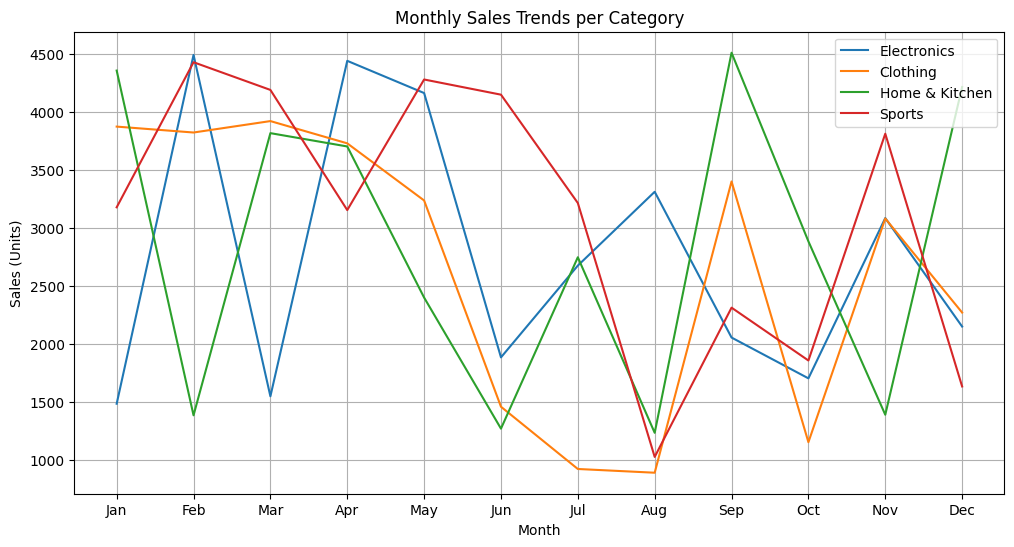

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
for column in ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']:
    plt.plot(sales_df.index, sales_df[column], label=column)

plt.title('Monthly Sales Trends per Category')
plt.xlabel('Month')
plt.ylabel('Sales (Units)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Calculate the percentage change between consecutive months for each category
sales_growth_per_category = sales_df.pct_change().dropna()

# Calculate the average sales growth for each category
average_sales_growth_per_category = sales_growth_per_category.mean()

print("\nAverage Sales Growth Between Consecutive Months Per Category:")
print(average_sales_growth_per_category)


Average Sales Growth Between Consecutive Months Per Category:
Electronics       0.295860
Clothing          0.224146
Home & Kitchen    0.424033
Sports            0.096088
dtype: float64


In [3]:
# Define column names and index (months)
column_names = ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']
month_names = pd.date_range(start='2023-01-01', periods=12, freq='MS').strftime('%b').tolist()

# Create the DataFrame
sales_df = pd.DataFrame(sales_data, columns=column_names, index=month_names)

print("Sales DataFrame created:")
display(sales_df.head())

Sales DataFrame created:


,Electronics,Clothing,Home & Kitchen,Sports
Jan,1482,4557,4357,3177
Feb,4492,4497,1382,4429
Mar,1546,4613,3817,4190
Apr,4441,4387,3702,3153
May,4163,3807,2398,4280
